In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("ushape.csv")

In [3]:
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


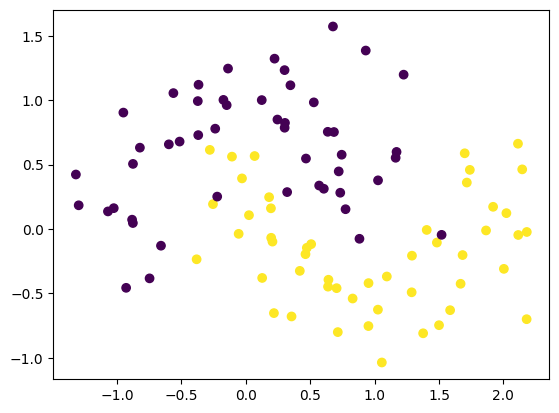

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X=df.iloc[:,0:2].values
y=df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import  Sequential 
from keras.layers import Dense

In [7]:
model=Sequential()
model.add(Dense(10,activation='tanh',input_dim=2))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

e:\Deep_Learning\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.get_weights()

[array([[ 0.01135015,  0.19792026,  0.62799996, -0.37149817,  0.45859617,
          0.27632773, -0.03141022,  0.08365476, -0.6674459 , -0.28701094],
        [-0.6820213 , -0.41288486,  0.12306696, -0.70668393, -0.4471907 ,
          0.30432433, -0.19919682,  0.08873886, -0.06526911,  0.24906981]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.3171481 ,  0.3504768 ,  0.41465378,  0.11492461, -0.1538358 ,
         -0.28075486, -0.27435583,  0.01318306, -0.44908756, -0.15458539],
        [-0.03662723,  0.0271278 ,  0.4559281 ,  0.158845  , -0.04658389,
          0.49076366, -0.14665103,  0.1344499 ,  0.10794187,  0.18084776],
        [ 0.28206688,  0.22778058,  0.370579  ,  0.36551535,  0.01154053,
          0.0128395 , -0.05779883,  0.1963954 ,  0.38031143,  0.40363353],
        [ 0.539237  ,  0.3678193 ,  0.44668478, -0.14912868, -0.04888037,
          0.07993466,  0.32416755, -0.30003712,  0.4150859 , -0.26726064],
        [ 0.45789

In [9]:
initial_weights=model.get_weights()


In [10]:
# ===========================
# First Hidden Layer
# ===========================

# Weight matrix for the first layer
# Shape = (2, 10)
# 2 input features -> 10 neurons
#
# np.random.randn() generates random numbers from a normal distribution.
# Multiplying by sqrt(1/2) is called He Initialization.
# It keeps the variance of activations stable and helps prevent
# exploding or vanishing gradients.
initial_weights[0] = np.random.randn(2, 10) * np.sqrt(1 / 2)

# Bias vector for the first layer
# Initialized with zeros.
# Shape = (10,)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)


# ===========================
# Second Hidden Layer
# ===========================

# Weight matrix
# Shape = (10, 10)
# 10 neurons from previous layer -> 10 neurons
initial_weights[2] = np.random.randn(10, 10) * np.sqrt(1 / 10)

# Bias vector
initial_weights[3] = np.zeros(model.get_weights()[3].shape)


# ===========================
# Third Hidden Layer
# ===========================

# Weight matrix
# Shape = (10, 10)
initial_weights[4] = np.random.randn(10, 10) * np.sqrt(1 / 10)

# Bias vector
initial_weights[5] = np.zeros(model.get_weights()[5].shape)


# ===========================
# Fourth Hidden Layer
# ===========================

# Weight matrix
# Shape = (10, 10)
initial_weights[6] = np.random.randn(10, 10) * np.sqrt(1 / 10)

# Bias vector
initial_weights[7] = np.zeros(model.get_weights()[7].shape)


# ===========================
# Output Layer
# ===========================

# Weight matrix
# Shape = (10, 1)
# 10 neurons -> 1 output neuron
initial_weights[8] = np.random.randn(10, 1) * np.sqrt(1 / 10)

# Output layer bias
initial_weights[9] = np.zeros(model.get_weights()[9].shape)


# ===========================
# Set all the manually created
# weights into the model
# ===========================
model.set_weights(initial_weights)

In [11]:
model.get_weights()

[array([[-0.41531873, -0.1181673 , -1.3469375 ,  0.819755  ,  0.8414738 ,
          0.17780477, -1.0646336 ,  0.28400502,  0.3813032 , -0.11169746],
        [-0.5396441 , -1.6327136 ,  0.36831027,  0.4134636 ,  0.62008286,
         -0.12340462, -0.4314975 , -0.338685  ,  0.944774  ,  0.04029062]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-1.16440527e-01, -7.49012351e-01,  2.76703656e-01,
          1.57597944e-01, -1.98830992e-01, -3.46094429e-01,
          5.02494574e-01, -1.21670954e-01, -3.55986893e-01,
          1.39812240e-02],
        [ 1.33268520e-01, -2.71662623e-01, -3.47357057e-02,
         -1.81341425e-01,  4.56839144e-01,  2.66613632e-01,
         -4.01899755e-01, -2.84111470e-01, -2.33089298e-01,
         -4.07384694e-01],
        [ 4.14674252e-01, -4.23938245e-01, -3.46314698e-01,
         -8.31024587e-01, -3.78809899e-01,  2.55752325e-01,
         -9.05752182e-03,  5.55402897e-02, -2.41609979e-02,
          4.0329682

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

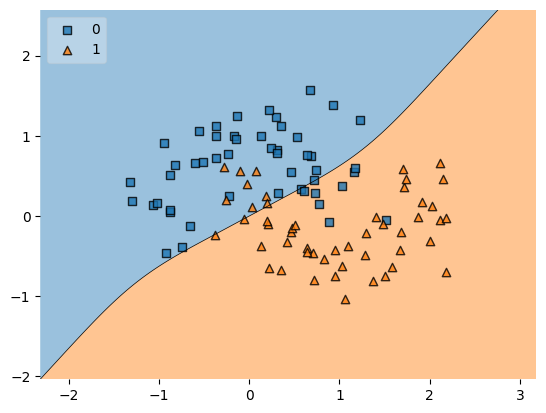

In [12]:

from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'),clf=model,legend=2)

